In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
Fake=pd.read_csv("fake.csv")

In [5]:
Fake.head()

,uuid,ord_in_thread,author,published,title,text,language,crawled,site_url,country,domain_rank,thread_title,spam_score,main_img_url,replies_count,participants_count,likes,comments,shares,type
0,6a175f46bcd24d39b3e962ad0f29936721db70db,0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,Muslims BUSTED: They Stole Millions In Gov’t B...,Print They should pay all the back all the mon...,english,2016-10-27T01:49:27.168+03:00,100percentfedup.com,US,25689.0,Muslims BUSTED: They Stole Millions In Gov’t B...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
1,2bdc29d12605ef9cf3f09f9875040a7113be5d5b,0,reasoning with facts,2016-10-29T08:47:11.259+03:00,Re: Why Did Attorney General Loretta Lynch Ple...,Why Did Attorney General Loretta Lynch Plead T...,english,2016-10-29T08:47:11.259+03:00,100percentfedup.com,US,25689.0,Re: Why Did Attorney General Loretta Lynch Ple...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
2,c70e149fdd53de5e61c29281100b9de0ed268bc3,0,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,BREAKING: Weiner Cooperating With FBI On Hilla...,Red State : \nFox News Sunday reported this mo...,english,2016-10-31T01:41:49.479+02:00,100percentfedup.com,US,25689.0,BREAKING: Weiner Cooperating With FBI On Hilla...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
3,7cf7c15731ac2a116dd7f629bd57ea468ed70284,0,Fed Up,2016-11-01T05:22:00.000+02:00,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,Email Kayla Mueller was a prisoner and torture...,english,2016-11-01T15:46:26.304+02:00,100percentfedup.com,US,25689.0,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,0.068,http://100percentfedup.com/wp-content/uploads/...,0,0,0,0,0,bias
4,0206b54719c7e241ffe0ad4315b808290dbe6c0f,0,Fed Up,2016-11-01T21:56:00.000+02:00,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,Email HEALTHCARE REFORM TO MAKE AMERICA GREAT ...,english,2016-11-01T23:59:42.266+02:00,100percentfedup.com,US,25689.0,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,0.865,http://100percentfedup.com/wp-content/uploads/...,0,0,0,0,0,bias


In [6]:
Fake.shape

(12999, 20)

In [24]:
Fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12999 entries, 0 to 12998
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   uuid                12999 non-null  object 
 1   ord_in_thread       12999 non-null  int64  
 2   author              10575 non-null  object 
 3   published           12999 non-null  object 
 4   title               12319 non-null  object 
 5   text                12953 non-null  object 
 6   language            12999 non-null  object 
 7   crawled             12999 non-null  object 
 8   site_url            12999 non-null  object 
 9   country             12823 non-null  object 
 10  domain_rank         8776 non-null   float64
 11  thread_title        12987 non-null  object 
 12  spam_score          12999 non-null  float64
 13  main_img_url        9356 non-null   object 
 14  replies_count       12999 non-null  int64  
 15  participants_count  12999 non-null  int64  
 16  like

In [25]:
Fake.rename(columns={"uuid":"Id"},inplace=True)

In [26]:
Fake.columns

Index(['Id', 'ord_in_thread', 'author', 'published', 'title', 'text',
       'language', 'crawled', 'site_url', 'country', 'domain_rank',
       'thread_title', 'spam_score', 'main_img_url', 'replies_count',
       'participants_count', 'likes', 'comments', 'shares', 'type'],
      dtype='object')

In [27]:
Fake["published"]=pd.to_datetime(Fake["published"],utc=True)
Fake["crawled"]=pd.to_datetime(Fake["crawled"],utc=True)

In [28]:
Fake[["published","crawled"]]

,published,crawled
0,2016-10-26 18:41:00+00:00,2016-10-26 22:49:27.168000+00:00
1,2016-10-29 05:47:11.259000+00:00,2016-10-29 05:47:11.259000+00:00
2,2016-10-30 23:41:49.479000+00:00,2016-10-30 23:41:49.479000+00:00
3,2016-11-01 03:22:00+00:00,2016-11-01 13:46:26.304000+00:00
4,2016-11-01 19:56:00+00:00,2016-11-01 21:59:42.266000+00:00
...,...,...
12994,2016-10-26 20:58:00+00:00,2016-10-26 21:37:46.194000+00:00
12995,2016-10-26 21:02:00+00:00,2016-10-26 21:37:46.220000+00:00
12996,2016-10-26 21:06:00+00:00,2016-10-26 21:37:46.244000+00:00
12997,2016-10-26 21:09:00+00:00,2016-10-26 21:37:46.247000+00:00


In [29]:
Fake.insert(8,"crawled_day_by_day",pd.to_datetime(Fake["crawled"],utc=True).dt.strftime('%Y-%m-%d'))
Fake.insert(4,"published_day_by_day",pd.to_datetime(Fake["published"],utc=True).dt.strftime("%Y-%m-%d"))

In [30]:
Fake.isnull().sum()

Id                         0
ord_in_thread              0
author                  2424
published                  0
published_day_by_day       0
title                    680
text                      46
language                   0
crawled                    0
crawled_day_by_day         0
site_url                   0
country                  176
domain_rank             4223
thread_title              12
spam_score                 0
main_img_url            3643
replies_count              0
participants_count         0
likes                      0
comments                   0
shares                     0
type                       0
dtype: int64

In [31]:
Fake.duplicated().sum()

np.int64(0)

In [32]:
Fake.describe()

,ord_in_thread,domain_rank,spam_score,replies_count,participants_count,likes,comments,shares
count,12999.000000,8776.000000,12999.000000,12999.000000,12999.000000,12999.000000,12999.000000,12999.000000
mean,0.891530,38092.996582,0.026122,1.383183,1.727518,10.831833,0.038311,10.831833
std,6.486822,26825.487454,0.122889,9.656838,6.884239,79.798949,0.827335,79.798949
min,0.000000,486.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,17423.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,34478.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,60570.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,100.000000,98679.000000,1.000000,309.000000,240.000000,988.000000,65.000000,988.000000


In [33]:
columns=["ord_in_thread","language","country","type"]

for i in columns:
    print('\n', i, Fake[i].unique())


 ord_in_thread [  0   1   2   3   4   5   6   7   8   9  10  11  29  30  18  19  20  12
  21  13  15  16  17  25  23  14  94  95  96  97  98  63  65  64  66  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  93  99 100  50  51  52  53  54  55  57  58
  56  59  60  61  22  24  33  39  26  27  28  31  32  34  35  36  37  38
  40  41  42  43  44  45  46  47  48  49]

 language ['english' 'ignore' 'german' 'french' 'spanish' 'russian' 'greek'
 'finnish' 'portuguese' 'arabic' 'dutch' 'italian' 'turkish' 'norwegian'
 'chinese' 'polish']

 country ['US' 'CO' 'FR' 'DE' 'GB' 'CA' 'AU' 'EU' 'NL' 'LI' 'SG' 'IO' 'ME' 'TV'
 'ES' 'RU' 'IN' nan 'IR' 'EE' 'SE' 'ZA' 'IS' 'BG' 'CH']

 type ['bias' 'conspiracy' 'fake' 'bs' 'satire' 'hate' 'junksci' 'state']


In [34]:
Fake["author"]=Fake["author"].fillna("Unknown")
Fake["country"]=Fake["country"].fillna("Unknown")
Fake["title"]=Fake["title"].fillna("Unknown")
Fake["thread_title"]=Fake["thread_title"].fillna("No Thread Title")

In [35]:
Fake.dropna(subset=["text"])

,Id,ord_in_thread,author,published,published_day_by_day,title,text,language,crawled,crawled_day_by_day,...,domain_rank,thread_title,spam_score,main_img_url,replies_count,participants_count,likes,comments,shares,type
0,6a175f46bcd24d39b3e962ad0f29936721db70db,0,Barracuda Brigade,2016-10-26 18:41:00+00:00,2016-10-26,Muslims BUSTED: They Stole Millions In Gov’t B...,Print They should pay all the back all the mon...,english,2016-10-26 22:49:27.168000+00:00,2016-10-26,...,25689.0,Muslims BUSTED: They Stole Millions In Gov’t B...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
1,2bdc29d12605ef9cf3f09f9875040a7113be5d5b,0,reasoning with facts,2016-10-29 05:47:11.259000+00:00,2016-10-29,Re: Why Did Attorney General Loretta Lynch Ple...,Why Did Attorney General Loretta Lynch Plead T...,english,2016-10-29 05:47:11.259000+00:00,2016-10-29,...,25689.0,Re: Why Did Attorney General Loretta Lynch Ple...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
2,c70e149fdd53de5e61c29281100b9de0ed268bc3,0,Barracuda Brigade,2016-10-30 23:41:49.479000+00:00,2016-10-30,BREAKING: Weiner Cooperating With FBI On Hilla...,Red State : \nFox News Sunday reported this mo...,english,2016-10-30 23:41:49.479000+00:00,2016-10-30,...,25689.0,BREAKING: Weiner Cooperating With FBI On Hilla...,0.000,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
3,7cf7c15731ac2a116dd7f629bd57ea468ed70284,0,Fed Up,2016-11-01 03:22:00+00:00,2016-11-01,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,Email Kayla Mueller was a prisoner and torture...,english,2016-11-01 13:46:26.304000+00:00,2016-11-01,...,25689.0,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,0.068,http://100percentfedup.com/wp-content/uploads/...,0,0,0,0,0,bias
4,0206b54719c7e241ffe0ad4315b808290dbe6c0f,0,Fed Up,2016-11-01 19:56:00+00:00,2016-11-01,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,Email HEALTHCARE REFORM TO MAKE AMERICA GREAT ...,english,2016-11-01 21:59:42.266000+00:00,2016-11-01,...,25689.0,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,0.865,http://100percentfedup.com/wp-content/uploads/...,0,0,0,0,0,bias
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12994,f1b5d0e44803f48732bde854a9fdf95837219b12,2,replaceme,2016-10-26 20:58:00+00:00,2016-10-26,Unknown,It DOES allow you to put a dog face on top of ...,english,2016-10-26 21:37:46.194000+00:00,2016-10-26,...,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs
12995,36011ceba3647e1bea78299b68b6fb705a1fc1ad,3,Freedumb,2016-10-26 21:02:00+00:00,2016-10-26,Unknown,Wait till you see what happens to the valuatio...,english,2016-10-26 21:37:46.220000+00:00,2016-10-26,...,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs
12996,6995d1aa9ac99926106489b14b5530e85358059a,4,major major maj...,2016-10-26 21:06:00+00:00,2016-10-26,Unknown,I'm waiting for the one that puts a pussy on m...,english,2016-10-26 21:37:46.244000+00:00,2016-10-26,...,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs
12997,7de8ae90eee164eb756db6c8a3772288e11d7a94,5,beemasters,2016-10-26 21:09:00+00:00,2016-10-26,Unknown,$4 Billion even after they are known to be kee...,english,2016-10-26 21:37:46.247000+00:00,2016-10-26,...,2435.0,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,NaN,40,32,0,0,0,bs


In [36]:
Fake.drop(columns=['domain_rank', 'main_img_url'])

,Id,ord_in_thread,author,published,published_day_by_day,title,text,language,crawled,crawled_day_by_day,site_url,country,thread_title,spam_score,replies_count,participants_count,likes,comments,shares,type
0,6a175f46bcd24d39b3e962ad0f29936721db70db,0,Barracuda Brigade,2016-10-26 18:41:00+00:00,2016-10-26,Muslims BUSTED: They Stole Millions In Gov’t B...,Print They should pay all the back all the mon...,english,2016-10-26 22:49:27.168000+00:00,2016-10-26,100percentfedup.com,US,Muslims BUSTED: They Stole Millions In Gov’t B...,0.000,0,1,0,0,0,bias
1,2bdc29d12605ef9cf3f09f9875040a7113be5d5b,0,reasoning with facts,2016-10-29 05:47:11.259000+00:00,2016-10-29,Re: Why Did Attorney General Loretta Lynch Ple...,Why Did Attorney General Loretta Lynch Plead T...,english,2016-10-29 05:47:11.259000+00:00,2016-10-29,100percentfedup.com,US,Re: Why Did Attorney General Loretta Lynch Ple...,0.000,0,1,0,0,0,bias
2,c70e149fdd53de5e61c29281100b9de0ed268bc3,0,Barracuda Brigade,2016-10-30 23:41:49.479000+00:00,2016-10-30,BREAKING: Weiner Cooperating With FBI On Hilla...,Red State : \nFox News Sunday reported this mo...,english,2016-10-30 23:41:49.479000+00:00,2016-10-30,100percentfedup.com,US,BREAKING: Weiner Cooperating With FBI On Hilla...,0.000,0,1,0,0,0,bias
3,7cf7c15731ac2a116dd7f629bd57ea468ed70284,0,Fed Up,2016-11-01 03:22:00+00:00,2016-11-01,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,Email Kayla Mueller was a prisoner and torture...,english,2016-11-01 13:46:26.304000+00:00,2016-11-01,100percentfedup.com,US,PIN DROP SPEECH BY FATHER OF DAUGHTER Kidnappe...,0.068,0,0,0,0,0,bias
4,0206b54719c7e241ffe0ad4315b808290dbe6c0f,0,Fed Up,2016-11-01 19:56:00+00:00,2016-11-01,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,Email HEALTHCARE REFORM TO MAKE AMERICA GREAT ...,english,2016-11-01 21:59:42.266000+00:00,2016-11-01,100percentfedup.com,US,FANTASTIC! TRUMP'S 7 POINT PLAN To Reform Heal...,0.865,0,0,0,0,0,bias
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12994,f1b5d0e44803f48732bde854a9fdf95837219b12,2,replaceme,2016-10-26 20:58:00+00:00,2016-10-26,Unknown,It DOES allow you to put a dog face on top of ...,english,2016-10-26 21:37:46.194000+00:00,2016-10-26,zerohedge.com,US,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,40,32,0,0,0,bs
12995,36011ceba3647e1bea78299b68b6fb705a1fc1ad,3,Freedumb,2016-10-26 21:02:00+00:00,2016-10-26,Unknown,Wait till you see what happens to the valuatio...,english,2016-10-26 21:37:46.220000+00:00,2016-10-26,zerohedge.com,US,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,40,32,0,0,0,bs
12996,6995d1aa9ac99926106489b14b5530e85358059a,4,major major maj...,2016-10-26 21:06:00+00:00,2016-10-26,Unknown,I'm waiting for the one that puts a pussy on m...,english,2016-10-26 21:37:46.244000+00:00,2016-10-26,zerohedge.com,US,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,40,32,0,0,0,bs
12997,7de8ae90eee164eb756db6c8a3772288e11d7a94,5,beemasters,2016-10-26 21:09:00+00:00,2016-10-26,Unknown,$4 Billion even after they are known to be kee...,english,2016-10-26 21:37:46.247000+00:00,2016-10-26,zerohedge.com,US,"Snapchat To Raise Up To $4 Billion In IPO, Val...",0.000,40,32,0,0,0,bs


In [37]:
Fake["author"].apply(lambda x:1 if x=="Unknown" else 0)

0        0
1        0
2        0
3        0
4        0
        ..
12994    0
12995    0
12996    0
12997    0
12998    0
Name: author, Length: 12999, dtype: int64

In [38]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91990\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91990\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [39]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [40]:
Fake["Full_text"]=Fake["title"]+" "+Fake["text"]+" "+Fake["thread_title"]

In [41]:
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r'http\S+|[^a-zA-Z]', ' ', str(text))
    words = text.lower().split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

Fake['clean_text'] = Fake['Full_text'].apply(preprocess)

In [42]:
Fake["clean_text"]

0        muslim busted stole million gov benefit print ...
1        attorney general loretta lynch plead fifth att...
2        breaking weiner cooperating fbi hillary email ...
3        pin drop speech father daughter kidnapped kill...
4        fantastic trump point plan reform healthcare b...
                               ...                        
12994    unknown allow put dog face top real face b sou...
12995    unknown wait till see happens valuation releas...
12996    unknown waiting one put pussy face snapchat ra...
12997    unknown billion even known keeping supposedly ...
12998    unknown course else would disceminate teen kid...
Name: clean_text, Length: 12999, dtype: object

In [43]:
Fake['word_count']=Fake['clean_text'].apply(lambda x: len(x.split()))
Fake['avg_word_length'] = Fake['clean_text'].apply(lambda x: np.mean([len(w) for w in x.split()]) if x else 0)

Fake["Exclamations"]=Fake["title"].apply(lambda x: x.count('!'))
Fake["Questions"]=Fake["title"].apply(lambda x: x.count('?'))
Fake["Title_len"]=Fake["title"].apply(len)

In [115]:
pip install textblob

In [44]:
from textblob import TextBlob

In [45]:
Fake["sentiment"]=Fake["Full_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

In [46]:
from collections import Counter

fake_words=" ".join(Fake[Fake["type"]=="Fake"]["clean_text"]).split()
real_words=" ".join(Fake[Fake["type"]=="Real"]["clean_text"]).split()

print(Counter(fake_words).most_common(20))
print(Counter(real_words).most_common(20))

[]
[]


In [47]:
vectorizer=CountVectorizer(ngram_range=(2,2),max_features=20)
ngrams=vectorizer.fit_transform(Fake["clean_text"])

print(vectorizer.get_feature_names_out())

['american people' 'barack obama' 'bill clinton' 'clinton campaign'
 'clinton foundation' 'de la' 'donald trump' 'foreign policy'
 'hillary clinton' 'look like' 'mainstream medium' 'new york'
 'presidential election' 'saudi arabia' 'secretary state' 'united state'
 'wall street' 'white house' 'year ago' 'year old']


In [48]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(Fake['clean_text'])
y = Fake['type']

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

model=LogisticRegression()
model.fit(X_train,y_train)

print("Accuracy",model.score(X_test,y_test))

Accuracy 0.8973076923076924


In [50]:
feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

top_fake = np.argsort(coef)[-20:]
top_real = np.argsort(coef)[:20]

print("Fake indicators:", feature_names[top_fake])
print("Real indicators:", feature_names[top_real])

Fake indicators: ['gop' 'email' 'wire' 'comey' 'press' 'sheriff' 'facebook' 'published'
 'article' 'wnd' 'republican' 'ago' 'server' 'entirely' 'denial' 'via'
 'account' 'unknown' 'min' 'trump']
Real indicators: ['october' 'wikileaks' 'today' 'make' 'one' 'truth' 'life' 'also' 'duke'
 'many' 'israel' 'much' 'water' 'anti' 'well' 'like' 'saudi' 'however'
 'attack' 'made']


<Axes: >

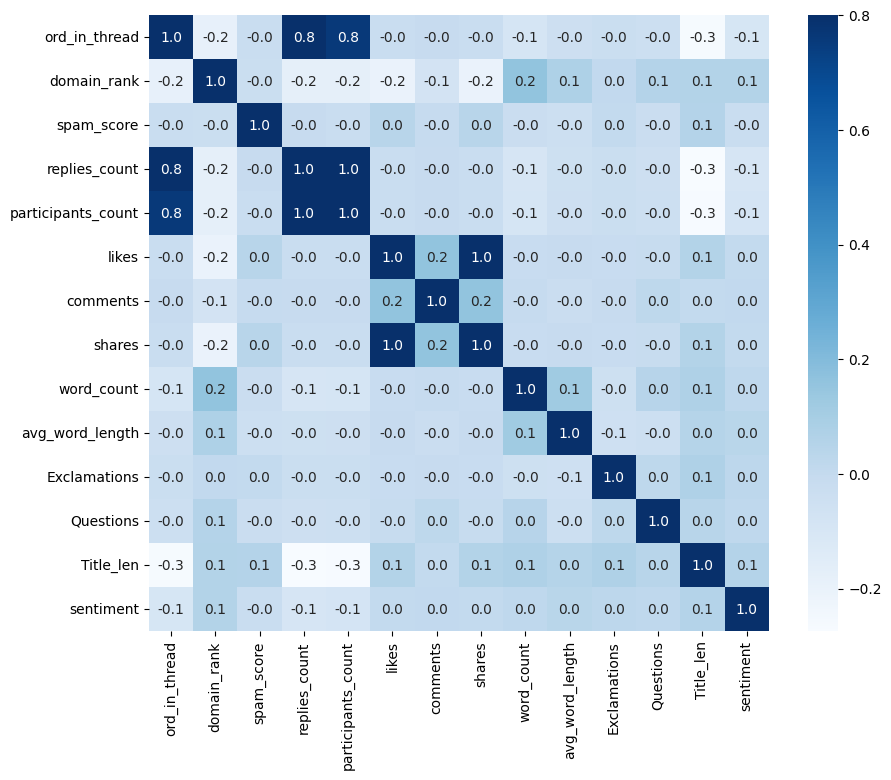

In [51]:
plt.figure(figsize=[10,8])
sns.heatmap(Fake.corr(numeric_only=True),vmin=None,
    vmax=0.8,
    cmap='Blues',
    annot=True,
    fmt='.1f',
    linecolor='white',
    cbar=True)

[]

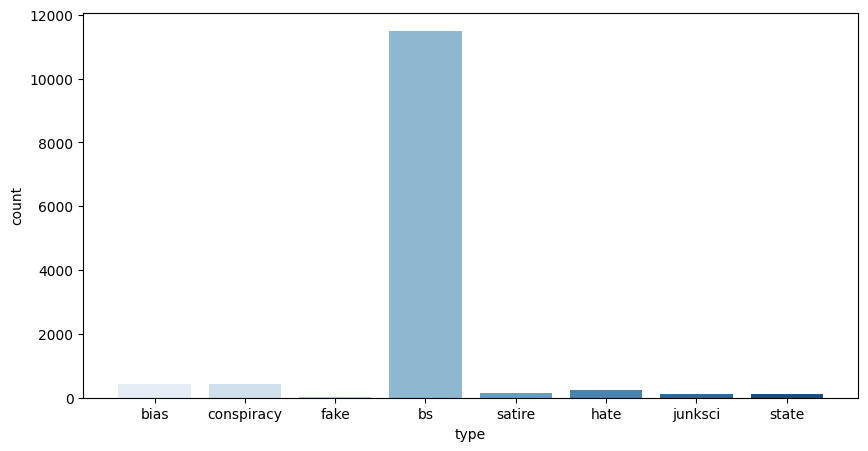

In [52]:
plt.figure(figsize=[10,5])
sns.countplot(x="type",hue='type',data=Fake,palette='Blues')
plt.plot()

[]

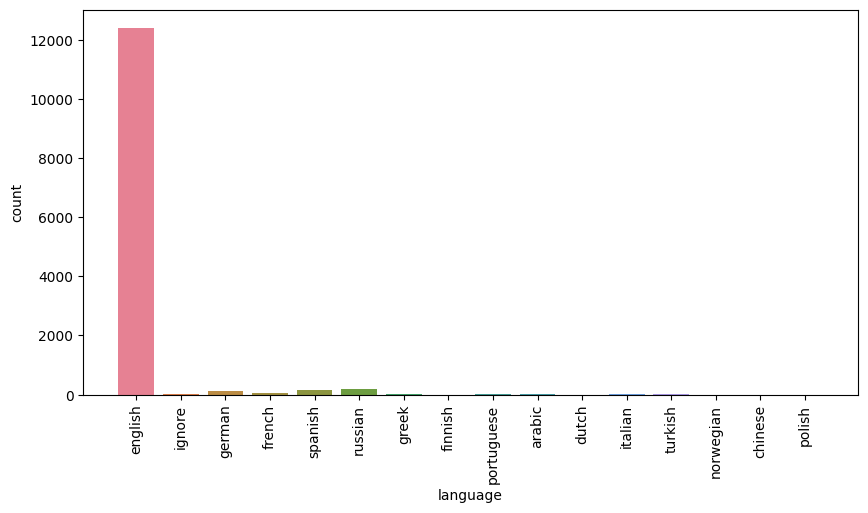

In [53]:
plt.figure(figsize=[10,5])
sns.countplot(x="language",hue='language',data=Fake)
plt.xticks(rotation=90)
plt.plot()

[]

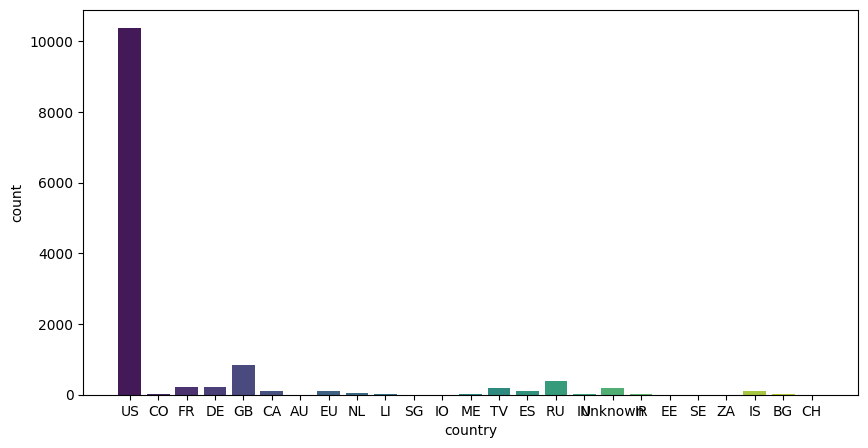

In [54]:
plt.figure(figsize=(10,5))
sns.countplot(x='country',hue='country',legend=False,data=Fake,palette='viridis')
plt.plot()

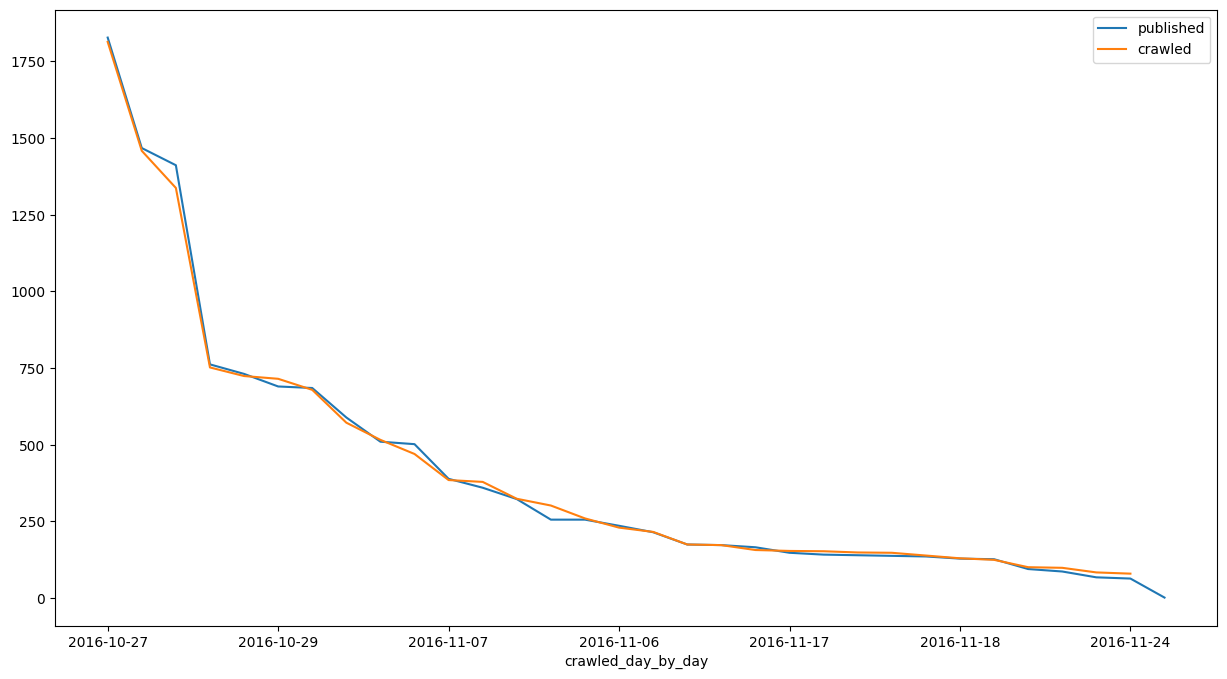

In [57]:
plt.figure(figsize=(15,8))
Fake['published_day_by_day'].value_counts().plot(kind='line',label='published')
Fake['crawled_day_by_day'].value_counts().plot(kind='line',label='crawled')
plt.legend()

Text(0.5, 0, 'day')

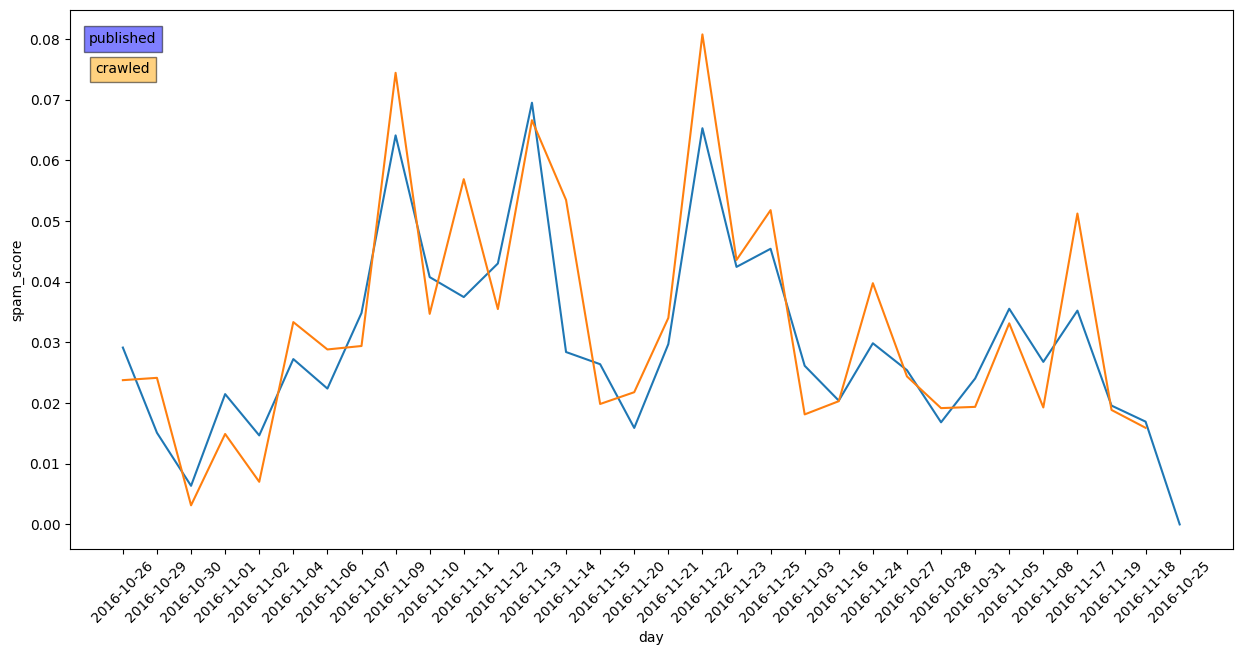

In [62]:
plt.figure(figsize=(15,7))
sns.lineplot(x='published_day_by_day',y='spam_score',data=Fake,errorbar=None)
sns.lineplot(x='crawled_day_by_day',y='spam_score',data=Fake,errorbar=None)
plt.text(0,0.08,'published', horizontalalignment='center', verticalalignment='center',bbox=dict(facecolor='blue', alpha=0.5))
plt.text(0,0.075,'crawled', horizontalalignment='center', verticalalignment='center',bbox=dict(facecolor='orange', alpha=0.5))
plt.xticks(rotation=45)
plt.xlabel('day')

In [ ]:
Fake.to_csv('fake_news_cleaning.csv')

In [13]:
Fake['type'].value_counts(normalize=True)*100

type
bs            88.406801
bias           3.407954
conspiracy     3.307947
hate           1.892453
satire         1.123163
state          0.930841
junksci        0.784676
fake           0.146165
Name: proportion, dtype: float64